# Actividad 6(Evaluación) - A01737199 - Isaac Barrón

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
Titanic = pd.read_csv('Titanic.csv')
Titanic.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [31]:
#a) Todas las columnas excepto: ” Unnamed: 0” y “parch”, al archivo .csv resultante llamarlo “STEP_1.csv”
STEP_1 = Titanic.drop(columns=["Unnamed: 0", "parch"])
STEP_1.to_csv("STEP_1.csv", index=False)

In [32]:
#carga nuevo archivo generado anteriormente 
STEP_2 = pd.read_csv("STEP_1.csv")

#aplicar a) En la columna (age): Reemplazar nulos con el valor “0”
STEP_2["age"] = STEP_2["age"].fillna(0)
#visualizar los registros nulos de la columna age
print(STEP_2["age"].isnull().sum())



0


In [33]:
#b) En las columnas (embarked y embark_town): Reemplazar nulos con el string: “unknown”
STEP_2[["embarked", "embark_town"]] = STEP_2[["embarked", "embark_town"]].fillna("unknown")
print(STEP_2[["embarked", "embark_town"]].isnull().sum())

embarked       0
embark_town    0
dtype: int64


In [34]:
#c) En la columna (deck): Reemplazar nulos con la letra “U”
STEP_2["deck"] = STEP_2["deck"].fillna("U")
print(STEP_2["deck"].isnull().sum())

0


In [35]:
print(STEP_2.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [36]:
#se guarda el resultado a STEP_2.csv
STEP_2.to_csv("STEP_2.csv", index=False)

In [47]:
# Cargar el archivo
step_3 = pd.read_csv("STEP_2.csv")

# Seleccionar todas las columnas numéricas
columnas_numericas = step_3.select_dtypes(include=["int64", "float64"]).columns

print("Columnas numéricas:")
print(columnas_numericas)

Columnas numéricas:
Index(['survived', 'pclass', 'age', 'sibsp', 'fare'], dtype='str')


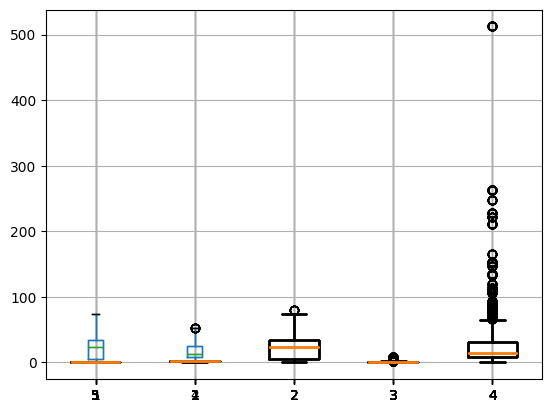

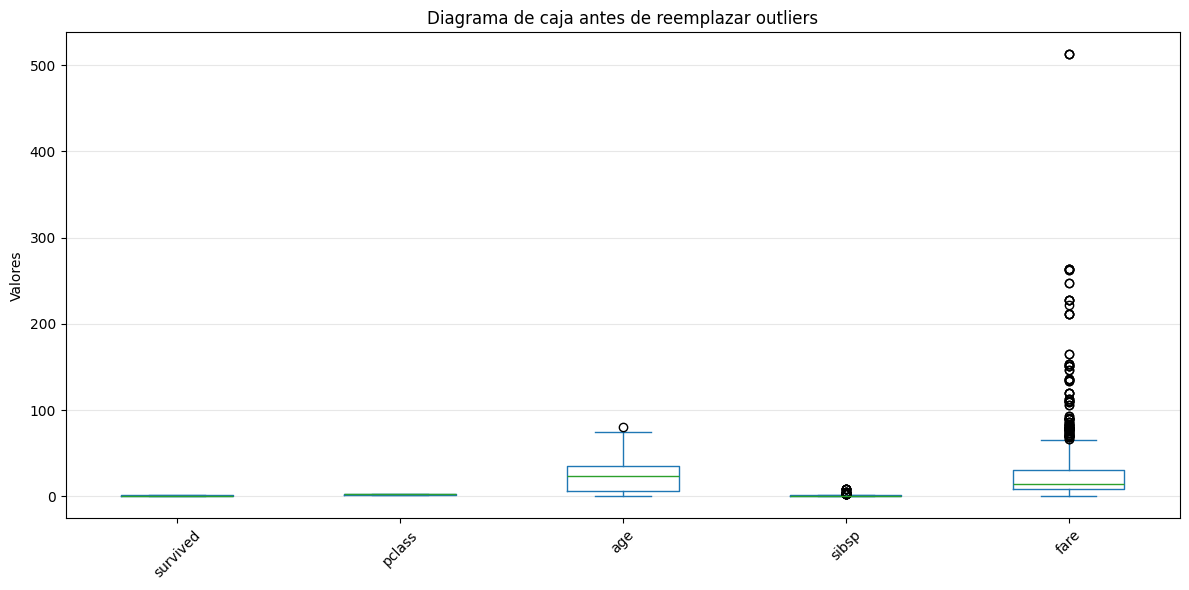

In [49]:
# Crear diagrama de caja general
step_3[columnas_numericas].plot(
    kind="box",
    figsize=(12, 6)
)

plt.title("Diagrama de caja antes de reemplazar outliers")
plt.ylabel("Valores")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
#aplicar el método de Rango Intercuartílico para reemplazar Outliers en columnas age y fare
Q1 = STEP_3[num_cols].quantile(0.25)
Q3 = STEP_3[num_cols].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

for col in ['age', 'fare']:
    STEP_3[col] = np.where((STEP_3[col] < limite_inferior[col]) | (STEP_3[col] > limite_superior[col]), np.nan, STEP_3[col])

#ver nulos en age y fare
print(STEP_3[['age', 'fare']].isnull().sum())

age       1
fare    116
dtype: int64


In [51]:
#remplazar nulos con la media de cada columna de age y fare
for col in ['age', 'fare']:
    mean_value = STEP_3[col].mean()
    STEP_3[col] = STEP_3[col].fillna(mean_value)

print(STEP_3[['age', 'fare']].isnull().sum())

age     0
fare    0
dtype: int64


In [53]:
#guardar el resultado a STEP_3.csv
STEP_3.to_csv("STEP_3.csv", index=False)

In [54]:
datos = pd.read_csv("STEP_3.csv")
datos.head()

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,7.250000,S,Third,man,True,U,Southampton,no,False
1,1,1,female,38.0,1,17.822091,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,7.925000,S,Third,woman,False,U,Southampton,yes,True
3,1,1,female,35.0,1,53.100000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,8.050000,S,Third,man,True,U,Southampton,no,True


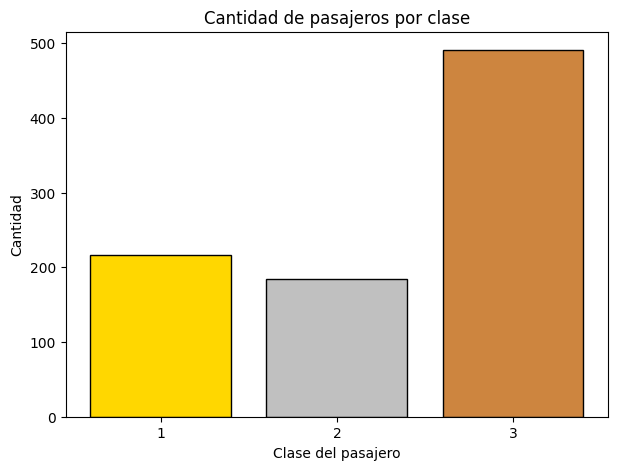

In [56]:
#Extraer características estadísticas a partir de un análisis univariado, a las siguientes variables
#  del archivo “STEP_3.csv”: ”pclass”, “sex”, “age”, “fare”, “embark_town” y “alive” .
# Mostrar los resultados obtenidos ,mediante gráficas.

#pclass
contpclass = datos["pclass"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    contpclass.index.astype(str),
    contpclass.values,
    color=["gold", "silver", "peru"],
    edgecolor="black"
)

plt.title("Cantidad de pasajeros por clase")
plt.xlabel("Clase del pasajero")
plt.ylabel("Cantidad")
plt.show()


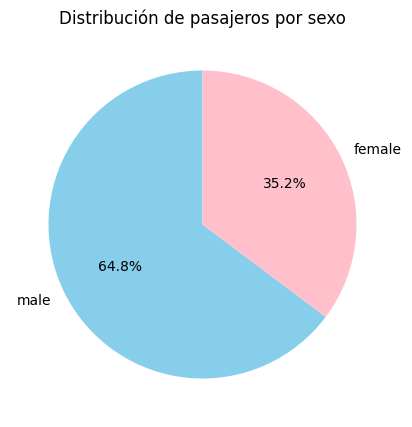

In [57]:
contsex = datos["sex"].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(
    contsex.values,
    labels=contsex.index,
    autopct="%1.1f%%",
    colors=["skyblue", "pink"],
    startangle=90
)

plt.title("Distribución de pasajeros por sexo")
plt.show()

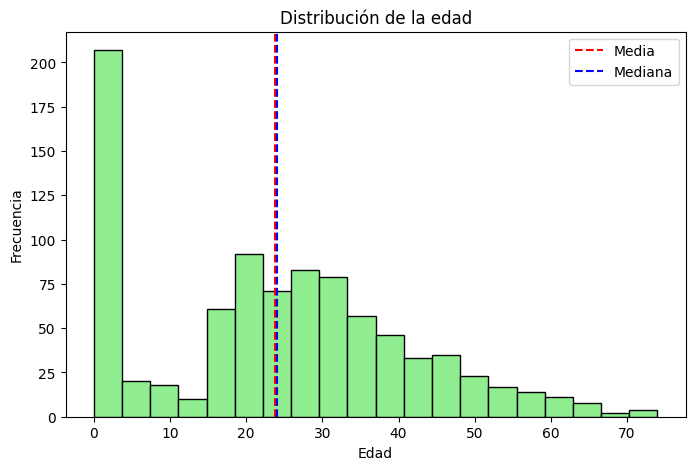

Media: 23.73614606741573
Mediana: 24.0
Desviación estándar: 17.4948259985699


In [58]:
media_age = datos["age"].mean()
mediana_age = datos["age"].median()

plt.figure(figsize=(8, 5))

plt.hist(
    datos["age"],
    bins=20,
    color="lightgreen",
    edgecolor="black"
)

plt.axvline(
    media_age,
    color="red",
    linestyle="--",
    label="Media"
)

plt.axvline(
    mediana_age,
    color="blue",
    linestyle="--",
    label="Mediana"
)

plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

print("Media:", media_age)
print("Mediana:", mediana_age)
print("Desviación estándar:", datos["age"].std())

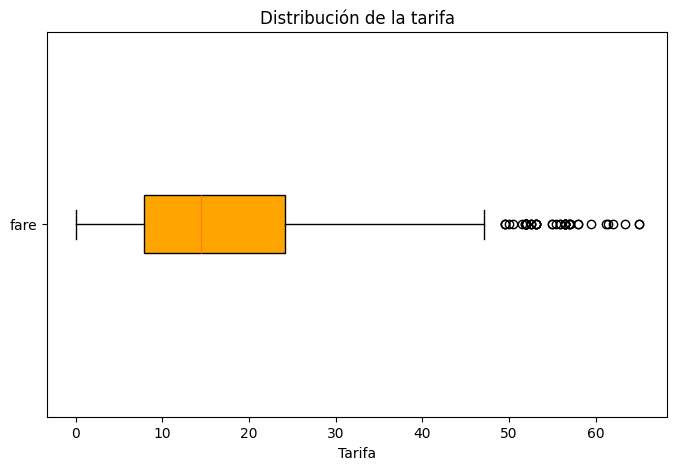

Media: 17.82209070967742
Mediana: 14.4542
Valor mínimo: 0.0
Valor máximo: 65.0


In [59]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    datos["fare"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="orange")
)

plt.title("Distribución de la tarifa")
plt.xlabel("Tarifa")
plt.yticks([1], ["fare"])
plt.show()

print("Media:", datos["fare"].mean())
print("Mediana:", datos["fare"].median())
print("Valor mínimo:", datos["fare"].min())
print("Valor máximo:", datos["fare"].max())

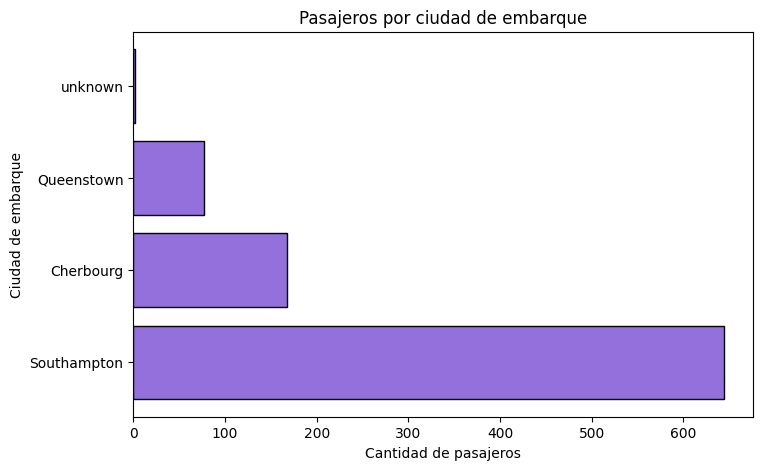

In [60]:
contembarque = datos["embark_town"].value_counts()

plt.figure(figsize=(8, 5))

plt.barh(
    contembarque.index,
    contembarque.values,
    color="mediumpurple",
    edgecolor="black"
)

plt.title("Pasajeros por ciudad de embarque")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Ciudad de embarque")
plt.show()

<Figure size 700x500 with 0 Axes>

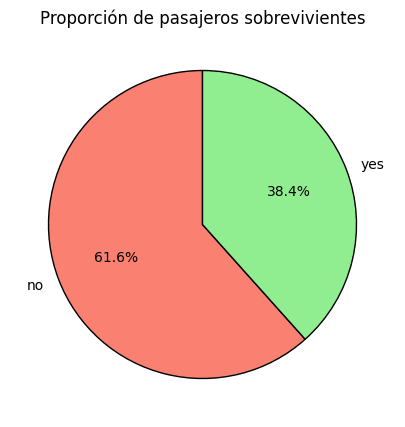

In [64]:
contalive = datos["alive"].value_counts()

plt.figure(figsize=(7, 5))

plt.pie(
    contalive.values,
    labels=contalive.index,
    autopct="%1.1f%%",
    colors=["salmon", "lightgreen"],
    startangle=90,
    wedgeprops={"edgecolor": "black"}
)

plt.title("Proporción de pasajeros sobrevivientes")
plt.show()